In [3]:
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt

# Initializing the Taxi environment
env = gym.make("Taxi-v4")

print(f"State space: {env.observation_space.n}")
print(f"Action space: {env.action_space.n}")

State space: 500
Action space: 6


In [4]:
def train_q_learning(env, alpha, gamma, epsilon, total_episodes=2000):
    """
    Trains a Q-learning agent on the Taxi environment.
    
    Parameters:
    - env: Gymnasium environment
    - alpha: Learning rate
    - gamma: Discount factor
    - epsilon: Exploration rate
    - total_episodes: Number of episodes to train
    
    Returns:
    - q_table: The learned Q-table
    - steps_per_episode: List of step counts per episode
    - returns_per_episode: List of total rewards per episode
    """
    state_space = env.observation_space.n
    action_space = env.action_space.n
    
    # Initializing Q-table with zeros
    q_table = np.zeros((state_space, action_space))
    
    steps_per_episode = []
    returns_per_episode = []
    
    for episode in range(total_episodes):
        state, info = env.reset()
        
        step_count = 0
        total_return = 0
        terminated = False
        truncated = False
        
        while not terminated and not truncated:
            # Epsilon-Greedy Action Selection
            if np.random.uniform(0, 1) < epsilon:
                action = env.action_space.sample()  # Explore: choose random action
            else:
                action = np.argmax(q_table[state, :])  # Exploit: choose best known action
            
            # Step in the environment
            next_state, reward, terminated, truncated, info = env.step(action)
            
            # Q-learning Update Rule (Bellman Optimality equation)
            old_value = q_table[state, action]
            next_max = np.max(q_table[next_state, :])
            q_table[state, action] = (1 - alpha) * old_value + alpha * (reward + gamma * next_max)
            
            # Track rewards and steps
            total_return += reward
            step_count += 1
            state = next_state
            
        steps_per_episode.append(step_count)
        returns_per_episode.append(total_return)
        
    return q_table, steps_per_episode, returns_per_episode

In [5]:
def plot_results(steps, returns, title_suffix=""):
    """
    Plots steps per episode and returns per episode with moving averages.
    """
    # Moving average window for smoother visual analysis
    window_size = 50
    steps_moving_avg = np.convolve(steps, np.ones(window_size)/window_size, mode='valid')
    returns_moving_avg = np.convolve(returns, np.ones(window_size)/window_size, mode='valid')
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot Steps per Episode
    axes[0].plot(steps, alpha=0.3, color='blue', label='Raw Steps')
    axes[0].plot(range(window_size - 1, len(steps)), steps_moving_avg, color='navy', label=f'{window_size}-Ep Moving Avg')
    axes[0].set_title(f'Steps per Episode {title_suffix}')
    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('Total Steps')
    axes[0].grid(True)
    axes[0].legend()
    
    # Plot Return per Episode
    axes[1].plot(returns, alpha=0.3, color='orange', label='Raw Return')
    axes[1].plot(range(window_size - 1, len(returns)), returns_moving_avg, color='darkred', label=f'{window_size}-Ep Moving Avg')
    axes[1].set_title(f'Return per Episode {title_suffix}')
    axes[1].set_xlabel('Episode')
    axes[1].set_ylabel('Return (Total Reward)')
    axes[1].grid(True)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

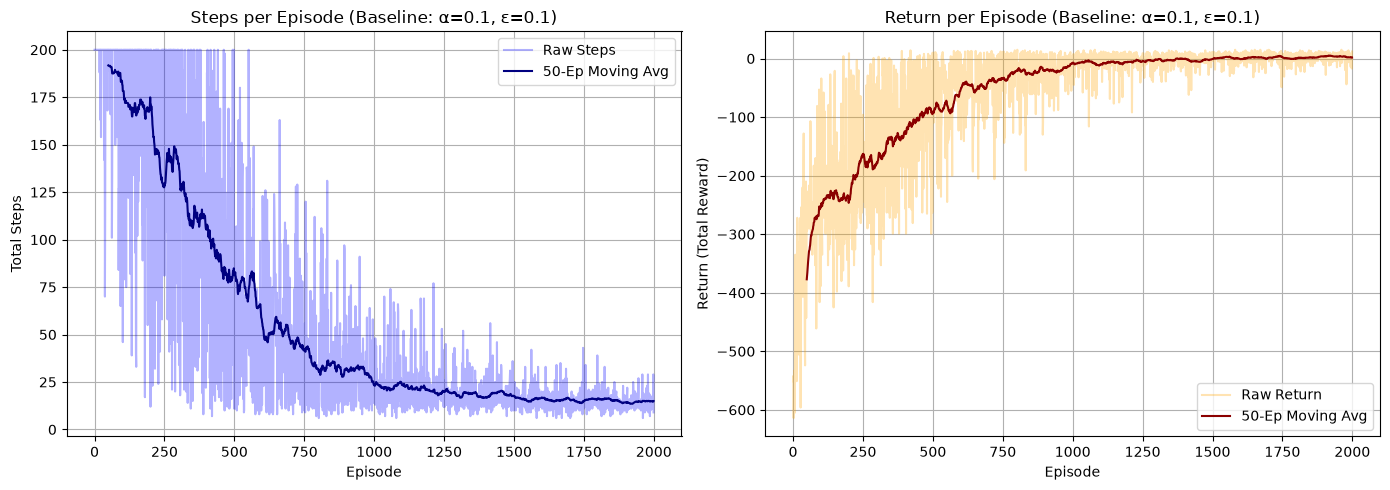

In [6]:
# Base Hyperparameters
base_alpha = 0.1
base_epsilon = 0.1
base_gamma = 0.9
episodes = 2000

# Training baseline model
base_q_table, base_steps, base_returns = train_q_learning(
    env, 
    alpha=base_alpha, 
    gamma=base_gamma, 
    epsilon=base_epsilon, 
    total_episodes=episodes
)

# Plotting Baseline Results
plot_results(base_steps, base_returns, title_suffix=f"(Baseline: α={base_alpha}, ε={base_epsilon})")

--- Training with Learning Rate α = 0.01 ---


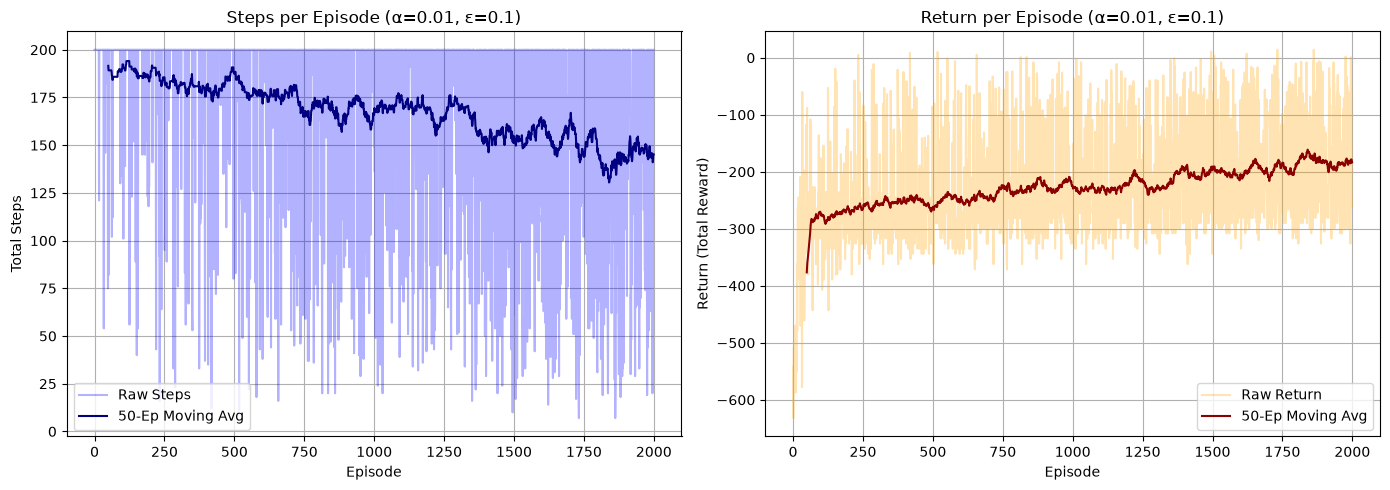

--- Training with Learning Rate α = 0.001 ---


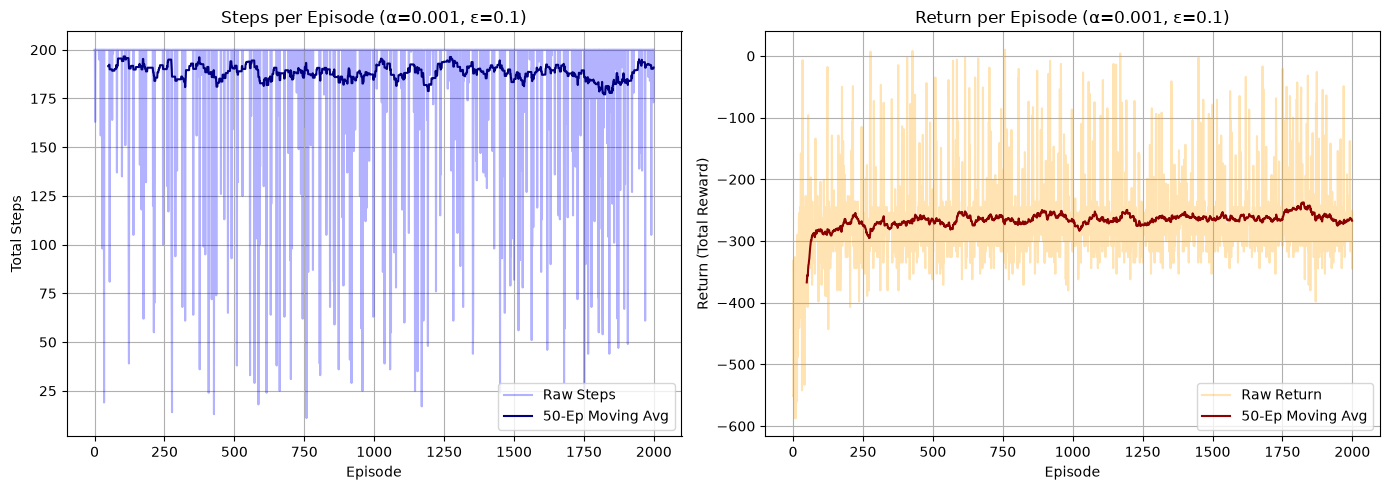

--- Training with Learning Rate α = 0.2 ---


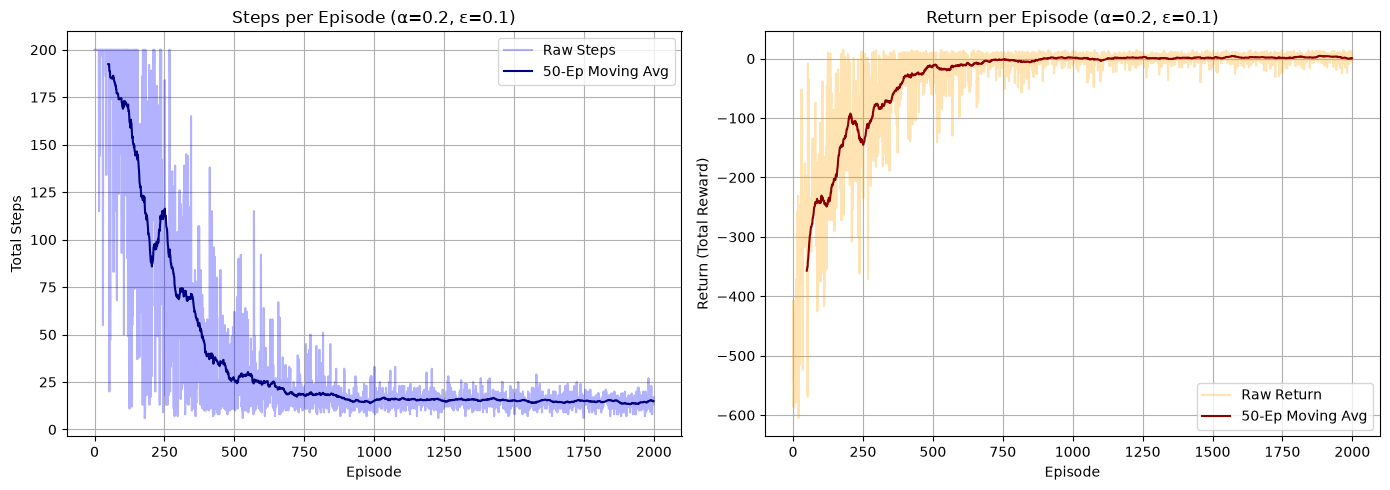

In [7]:
# Testing different Learning Rates (Alpha)
alphas_to_test = [0.01, 0.001, 0.2]

for test_alpha in alphas_to_test:
    print(f"--- Training with Learning Rate α = {test_alpha} ---")
    _, test_steps, test_returns = train_q_learning(
        env, 
        alpha=test_alpha, 
        gamma=base_gamma, 
        epsilon=base_epsilon, 
        total_episodes=episodes
    )
    
    # Plot results for this specific alpha
    plot_results(test_steps, test_returns, title_suffix=f"(α={test_alpha}, ε={base_epsilon})")

--- Training Final Optimized Model (α=0.2, ε=0.1) ---


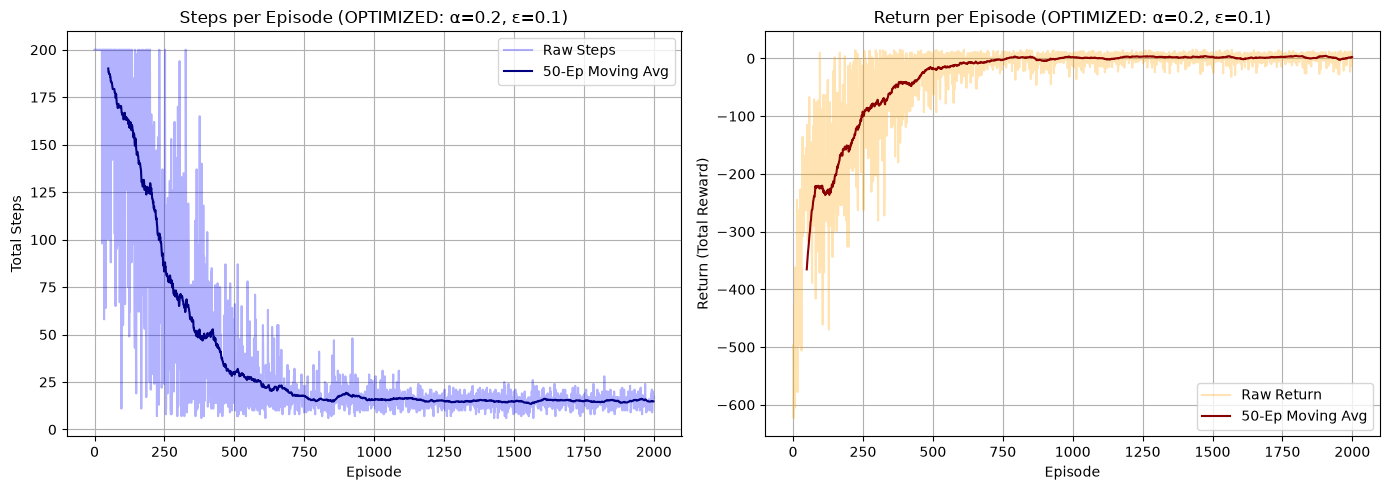

In [8]:
# Final Optimized Hyperparameters
best_alpha = 0.2    
best_epsilon = 0.1 
best_gamma = 0.9  

print(f"--- Training Final Optimized Model (α={best_alpha}, ε={best_epsilon}) ---")
best_q_table, best_steps, best_returns = train_q_learning(
    env, 
    alpha=best_alpha, 
    gamma=best_gamma, 
    epsilon=best_epsilon, 
    total_episodes=episodes
)

# Plot Final Results
plot_results(best_steps, best_returns, title_suffix=f"(OPTIMIZED: α={best_alpha}, ε={best_epsilon})")

In [9]:
def evaluate_agent(env, q_table, num_episodes=100):
    total_steps = []
    total_rewards = []
    penalties = 0
    
    for _ in range(num_episodes):
        state, info = env.reset()
        episode_reward = 0
        steps = 0
        terminated = False
        truncated = False
        
        while not terminated and not truncated:
            # Pure exploitation (greedy policy)
            action = np.argmax(q_table[state, :])
            next_state, reward, terminated, truncated, info = env.step(action)
            
            if reward == -10:
                penalties += 1
                
            episode_reward += reward
            steps += 1
            state = next_state
            
        total_steps.append(steps)
        total_rewards.append(episode_reward)
        
    print(f"Results over {num_episodes} evaluation episodes:")
    print(f"Average Steps per episode: {np.mean(total_steps):.2f}")
    print(f"Average Return per episode: {np.mean(total_rewards):.2f}")
    print(f"Total Illegal Actions / Penalties: {penalties}")

# Evaluate the optimized model
evaluate_agent(env, best_q_table)

Results over 100 evaluation episodes:
Average Steps per episode: 13.29
Average Return per episode: 7.71
Total Illegal Actions / Penalties: 0
